<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Biomedical_Discovery_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomedical Discovery Engine: Knowledge Graph Construction

This notebook outlines the process of building a knowledge graph connecting diseases, genes, drugs, and more using data from sources like Wikidata and PubMed.

In [1]:
!pip install SPARQLWrapper pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 6.2 MB/s eta 0:00:00


## 1. Fetching Data from Wikidata
We will use SPARQL to query Wikidata for disease-symptom relationships.

In [2]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

def get_disease_symptoms():
    endpoint_url = "https://query.wikidata.org/sparql"
    query = """
    SELECT ?diseaseLabel ?symptomLabel WHERE {
      ?disease wdt:P31 wd:Q12136. # instance of disease
      ?disease wdt:P780 ?symptom. # has symptom
      SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }
    }
    LIMIT 100
    """

    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    data = []
    for result in results["results"]["bindings"]:
        data.append({
            "disease": result["diseaseLabel"]["value"],
            "symptom": result["symptomLabel"]["value"]
        })

    return pd.DataFrame(data)

df_symptoms = get_disease_symptoms()
display(df_symptoms.head())

,disease,symptom
0,tuberculosis,cough
1,tuberculosis,fever
2,tuberculosis,night sweats
3,tuberculosis,hemoptysis
4,tuberculosis,chest pain


## 2. Visualizing the Knowledge Graph
We will use `networkx` to create a visual representation of the disease-symptom relationships we just extracted.

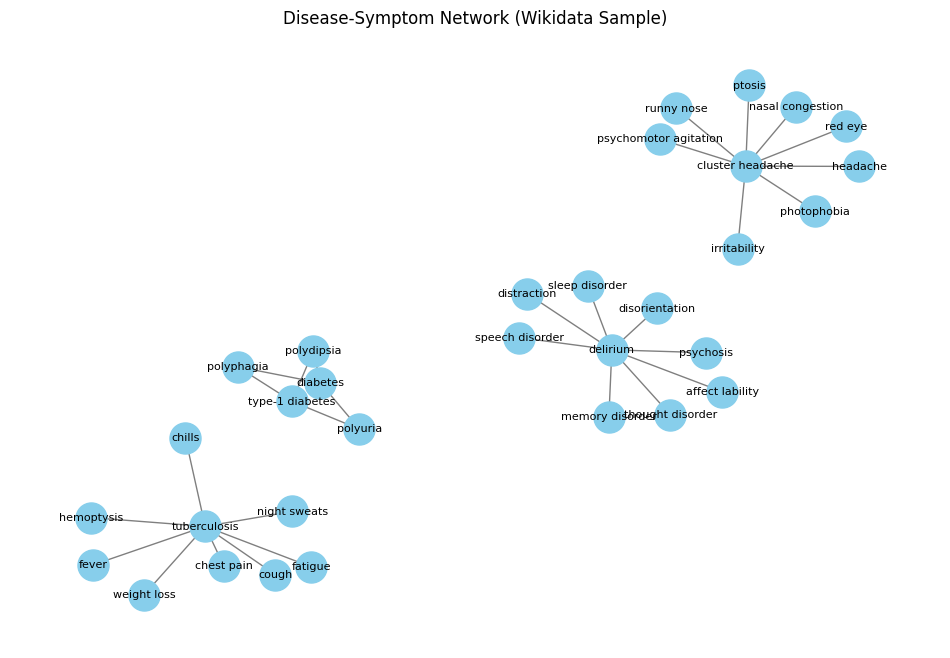

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(df):
    G = nx.Graph()

    # Add edges from the dataframe
    for _, row in df.iterrows():
        G.add_edge(row['disease'], row['symptom'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.15, iterations=20)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue')
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=8)

    plt.title("Disease-Symptom Network (Wikidata Sample)")
    plt.axis('off')
    plt.show()

# Visualize the first 30 relations for clarity in the plot
visualize_graph(df_symptoms.head(30))